# 📦 TurboEnvíos — Diagnóstico estadístico de la operación de última milla

**Análisis de Datos · Estadística descriptiva aplicada**
Dataset: `turboenvios_entregas.csv` · 50.000 entregas · junio 2026

---

## La pregunta de negocio

TurboEnvíos es una empresa de mensajería de última milla. La dirección nos entrega el registro de un mes completo de entregas y nos hace dos preguntas que valen dinero:

> **1. ¿Qué encarece nuestros envíos?** — para saber dónde optimizar el costo.
> **2. ¿Qué enoja a nuestros clientes?** — porque un cliente insatisfecho no vuelve.

Toda la estadística descriptiva existe para responder **tres preguntas sobre un conjunto de datos**: *¿dónde está el centro?*, *¿qué tan dispersos están los valores alrededor de ese centro?* y *¿qué posición ocupa cada dato?*. A esas tres añadiremos una cuarta, la que de verdad genera valor: *¿cómo se relacionan unas variables con otras?*.

Este notebook recorre ese camino **paso a paso**: cada celda de código va precedida de una explicación del concepto, su fórmula y la lectura de negocio del resultado. No buscamos calcular números bonitos, sino **convertir 50.000 filas en decisiones**.

In [1]:
import pandas as pd                     # pandas: trabajar con tablas (DataFrames). Lo renombramos a 'pd' por convención
import numpy as np                      # numpy: cálculo numérico con arrays. Renombrado a 'np' por convención
import matplotlib.pyplot as plt         # matplotlib: librería base para dibujar gráficos. 'plt' es el alias estándar
import seaborn as sns                   # seaborn: gráficos estadísticos más bonitos, construido encima de matplotlib

# --- Estilo visual coherente para todo el informe ---
sns.set_theme(style="whitegrid", font_scale=1.05)  # aplica un tema con rejilla blanca y agranda un 5% el texto
plt.rcParams["figure.figsize"] = (9, 5)            # tamaño por defecto de TODAS las figuras: 9 de ancho x 5 de alto (pulgadas)
plt.rcParams["axes.titlesize"] = 14                # tamaño de letra por defecto del título de cada gráfico
plt.rcParams["axes.titleweight"] = "bold"          # los títulos saldrán en negrita

# Paleta corporativa (naranja = acento, verde = positivo, azul = neutro)
NARANJA, VERDE, AZUL, GRIS, ROJO = "#d97642", "#3f9d6b", "#3f6f9d", "#8a8a8a", "#d81a1a" # guardamos 4 colores en código hexadecimal para reusarlos

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")  # al mostrar números, usar separador de miles y 2 decimales (ej: 8,380.67)
print("Entorno listo · pandas", pd.__version__, "· numpy", np.__version__)  # confirma que cargó e imprime las versiones instaladas


Entorno listo · pandas 3.0.3 · numpy 2.5.0


In [2]:
# read_csv: lee el archivo CSV y lo convierte en un DataFrame (tabla). encoding="latin-1" para que los acentos no se rompan.
# parse_dates=["fecha"]: le dice a pandas que la columna 'fecha' son fechas reales, no texto.
df = pd.read_csv("turboenvios_entregas.csv", parse_dates=["fecha"])

# df.shape devuelve (nº de filas, nº de columnas). [0] = filas, [1] = columnas. El :, pone separador de miles.
print(f"El dataset tiene {df.shape[0]:,} casos (entregas) y {df.shape[1]} variables (columnas)\n")
df.head()   # muestra las primeras 5 filas para echar un vistazo a cómo son los datos


El dataset tiene 50,000 casos (entregas) y 9 variables (columnas)



,pedido_id,fecha,zona,tipo_servicio,distancia_km,peso_kg,tiempo_entrega_min,costo_envio,calificacion_cliente
0,1,2026-06-07,Residencial,Estándar,13.40,0.96,89.50,"12,157.00",1.00
1,2,2026-06-20,Comercial,Estándar,7.30,5.07,57.10,"10,426.00",2.00
2,3,2026-06-29,Comercial,Estándar,2.25,1.49,43.00,"4,460.00",5.00
3,4,2026-06-15,Centro,Express,3.74,5.49,41.40,"11,186.00",2.00
4,5,2026-06-11,Periferia,Express,5.15,3.09,32.60,"9,907.00",5.00


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   pedido_id             50000 non-null  int64         
 1   fecha                 50000 non-null  datetime64[us]
 2   zona                  50000 non-null  str           
 3   tipo_servicio         50000 non-null  str           
 4   distancia_km          50000 non-null  float64       
 5   peso_kg               50000 non-null  float64       
 6   tiempo_entrega_min    50000 non-null  float64       
 7   costo_envio           50000 non-null  float64       
 8   calificacion_cliente  49500 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(1), str(2)
memory usage: 3.4 MB


In [4]:
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0]
print("Valores faltantes por columnas")
print(faltantes)
# .isnull().mean() 
print(f"\n{df['calificacion_cliente'].isnull().mean():.1%} de las entregas no tienen calificacion de cliente")

Valores faltantes por columnas
calificacion_cliente    500
dtype: int64

1.0% de las entregas no tienen calificacion de cliente


In [5]:
# Tabla de frecuencia de la variable 'zona'
frec = df["zona"].value_counts()                        # value_counts() cuenta cuántas veces aparece cada zona (frecuencia absoluta)
frec_rel = df["zona"].value_counts(normalize=True)*100  # normalize=True devuelve proporciones (0-1); *100 las pasa a porcentaje

tabla_zona = pd.DataFrame({                              # construimos una tabla nueva juntando las tres columnas calculadas
    "Frec. absoluta": frec,                             # el conteo crudo
    "Frec. relativa (%)": frec_rel.round(1),            # el porcentaje, redondeado a 1 decimal
    "Frec. acumulada (%)": frec_rel.cumsum().round(1),  # cumsum() suma acumulando fila a fila: 28.3, luego 28.3+27.7, etc.
})
tabla_zona           

,Frec. absoluta,Frec. relativa (%),Frec. acumulada (%)
zona,,,
Periferia,14171,28.30,28.30
Centro,13870,27.70,56.10
Comercial,8090,16.20,72.30
Industrial,7767,15.50,87.80
Residencial,6102,12.20,100.00


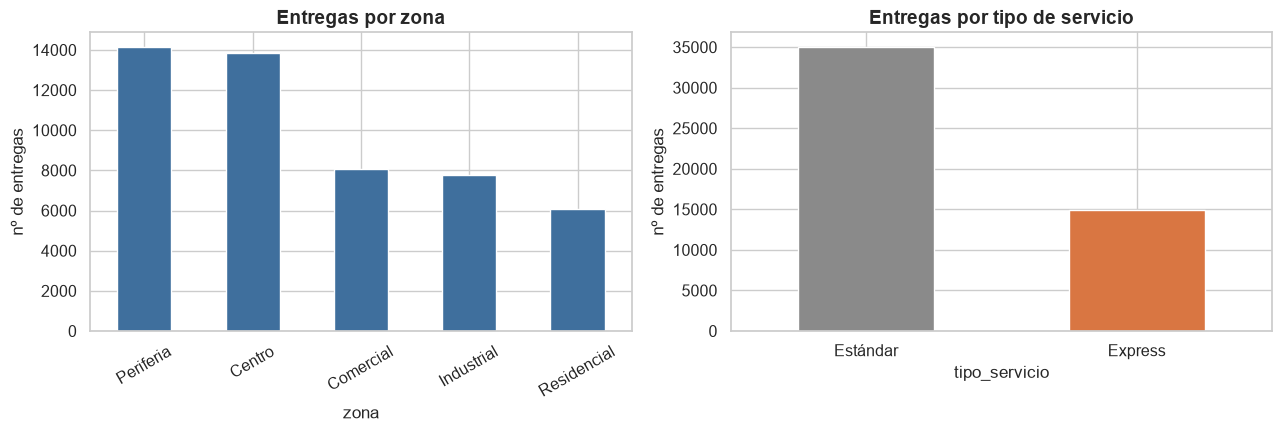

In [6]:
# Visualizamos las dos variables cualitativas
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df["zona"].value_counts().plot(kind="bar", ax=axes[0], color=AZUL)
axes[0].set_title("Entregas por zona")
axes[0].set_ylabel("nº de entregas")
axes[0].tick_params(axis="x", rotation=30)

df["tipo_servicio"].value_counts().plot(kind="bar", ax=axes[1], color=[GRIS, NARANJA])
axes[1].set_title("Entregas por tipo de servicio")
axes[1].set_ylabel("nº de entregas")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Lectura: Periferia y Centro concentran más de la mitad del volumen, son el corazón operativo, donde cualquier mejora tiene mas impacto, es estandar domina 70% frente a express 30%.

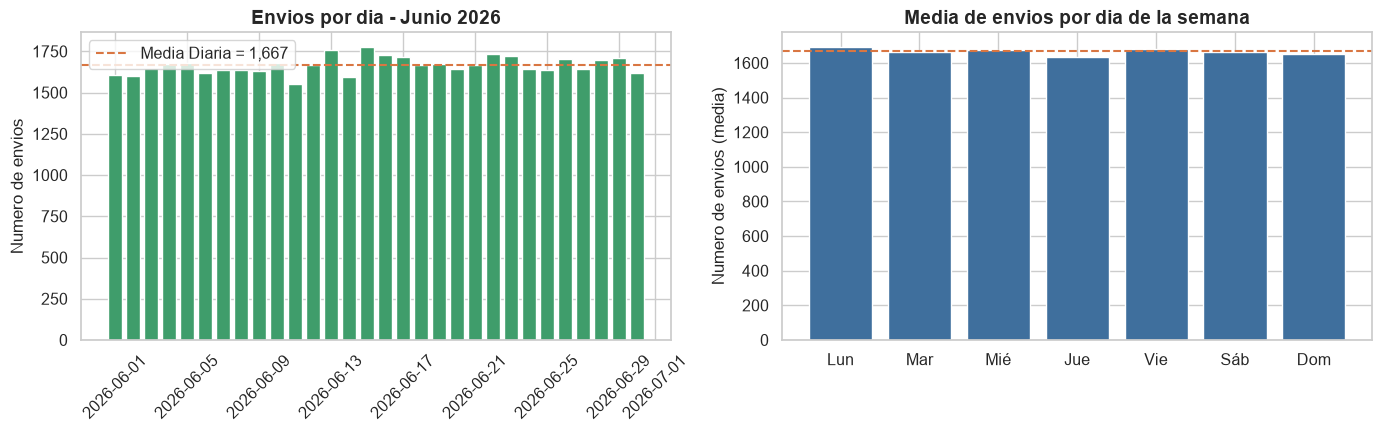

Días registrados      : 30
Media por día         : 1,666.7 envíos
Día MÁS activo        : 15-Jun con 1,777 envíos
Día MENOS activo      : 11-Jun con 1,555 envíos
Diferencia pico-valle : 14.3% sobre el mínimo


In [41]:
# Actividad a lo largo de Junio
# ¿Qué días de junio hubo más actividad? (agrupa por fecha)
envios_por_dia = df.groupby("fecha").size() # con size contamos cuantas filas (envios) cae en cada grupo
media_diaria = envios_por_dia.mean() # .mean() = promedio de envios por dia 

dias_nombre = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"] # para traducir 0...6 a nombre legible

# day of week
dow = df["fecha"].dt.dayofweek # Serie con el dia de la sema (0-6) de cada envio

# media por dia-de-sema = (total de envios de ese dia) / numero de fecha distintas de ese dia
media_dow = df.groupby(dow).size() / df.groupby(dow)["fecha"].nunique()
media_dow.index = [dias_nombre[i] for i in media_dow.index]

fig, axes = plt.subplots(1,2, figsize=(14, 4.5))
axes[0].bar(envios_por_dia.index, envios_por_dia.values, color=VERDE, width=0.8)
# Linea Horizontal axhline = dibuja una linea horizontal 
axes[0].axhline(media_diaria, color=NARANJA, linestyle="--", linewidth=1.5, label=f"Media Diaria = {media_diaria:,.0f}")
axes[0].set_title("Envios por dia - Junio 2026")
axes[0].set_ylabel('Numero de envios')
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
# Panel Derecho
axes[1].bar(media_dow.index, media_dow.values, color=AZUL, width=0.8)
axes[1].axhline(media_diaria, color=NARANJA, linestyle="--", linewidth=1.5)
axes[1].set_title("Media de envios por dia de la semana")
axes[1].set_ylabel('Numero de envios (media)')
plt.tight_layout()
plt.show()

# Resumen numérico de apoyo
print(f"Días registrados      : {envios_por_dia.size}")
print(f"Media por día         : {media_diaria:,.1f} envíos")
print(f"Día MÁS activo        : {envios_por_dia.idxmax():%d-%b} con {envios_por_dia.max():,} envíos")
print(f"Día MENOS activo      : {envios_por_dia.idxmin():%d-%b} con {envios_por_dia.min():,} envíos")
print(f"Diferencia pico-valle : {(envios_por_dia.max() / envios_por_dia.min() - 1) * 100:,.1f}% sobre el mínimo")

In [8]:
metricas = ["costo_envio", "tiempo_entrega_min", "distancia_km", "peso_kg"]

centro = pd.DataFrame({
    "Media": df[metricas].mean(),            # .mean() = media (promedio) de cada columna. Devuelve una Serie (una cifra por métrica)
    "Mediana": df[metricas].median(),        # .median() = mediana (el valor central al ordenar)
}).round(2)   
                               # .round(2) aplicado a TODA la tabla = redondea cada número a 2 decimales
centro["Media − Mediana"] = (centro["Media"] - centro["Mediana"]).round(2)  # pista del sesgo: cuánto se separan media y mediana
centro

,Media,Mediana,Media − Mediana
costo_envio,"8,380.67","7,939.00",441.67
tiempo_entrega_min,47.21,42.90,4.31
distancia_km,5.76,4.96,0.80
peso_kg,3.15,2.46,0.69


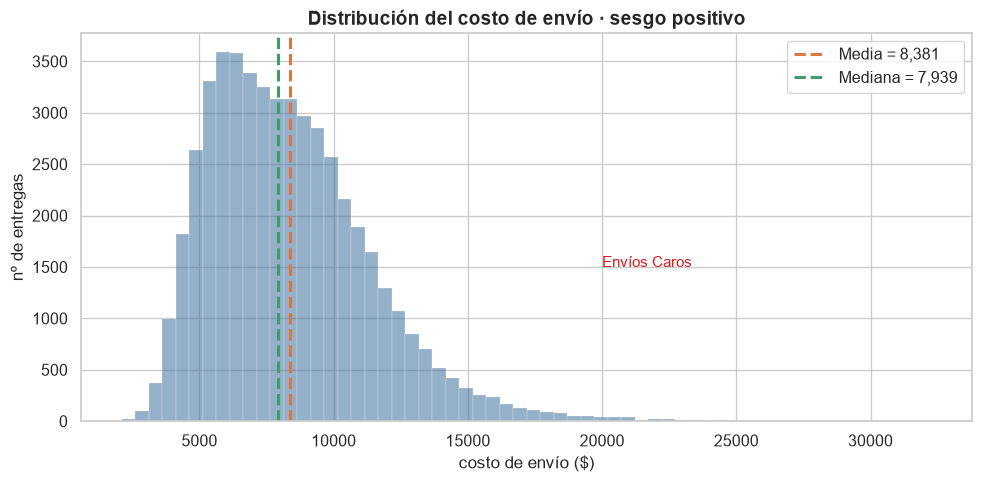

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["costo_envio"], bins=60, color=AZUL, alpha=0.55, edgecolor="white", linewidth=0.3)
media = df["costo_envio"].mean()          # media del costo, la guardamos para dibujar su línea
mediana = df["costo_envio"].median()      # mediana del costo
# lw=2.2 grosor, ls="--" estilo en linea discontinua , label="..." es el texto de la leyenda
ax.axvline(media, color=NARANJA, lw=2.2, ls="--", label=f"Media = {media:,.0f}")
ax.axvline(mediana, color=VERDE, lw=2.2, ls="--", label=f"Mediana = {mediana:,.0f}")
ax.set_title("Distribución del costo de envío · sesgo positivo")  # título del gráfico
ax.set_xlabel("costo de envío ($)") 
ax.set_ylabel("nº de entregas")
ax.annotate("Envíos Caros", xy=(20000, 1500), color=ROJO, fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

Lectura de negocio: la mayoria de los envios cuestan medio-bajo, pero existe una cola de envios caros hacen que arrastre la media por encima de la mediana

# Rango le medida mas simple (e insuficiente)

In [10]:
rango = (df[metricas].max() - df[metricas].min()).round(2)
pd.DataFrame({"Mínimo": df[metricas].min(), "Máximo": df[metricas].max(), "Rango": rango})

,Mínimo,Máximo,Rango
costo_envio,"2,102.00","32,278.00","30,176.00"
tiempo_entrega_min,5.00,300.00,295.00
distancia_km,0.61,40.00,39.39
peso_kg,0.16,30.00,29.84


In [11]:
dispersion = pd.DataFrame({                    # construimos una tabla resumen de dispersión para las 4 métricas
    "Media": df[metricas].mean(),             # .mean() = media (centro), la incluimos como referencia
    "Varianza": df[metricas].var(),           # .var() = varianza = promedio de las distancias al cuadrado respecto a la media. En pandas usa ddof=1 (muestral) por defecto
    "Desv. estándar (σ)": df[metricas].std(), # .std() = desviación estándar = raíz cuadrada de la varianza, ya en las unidades originales
}).round(2)                                    # redondea toda la tabla a 2 decimales
dispersion                   

,Media,Varianza,Desv. estándar (σ)
costo_envio,"8,380.67","9,358,190.27","3,059.12"
tiempo_entrega_min,47.21,849.00,29.14
distancia_km,5.76,11.77,3.43
peso_kg,3.15,6.28,2.51


In [12]:
col = "tiempo_entrega_min"   # variable de texto con el nombre de la columna; así no repetimos el string en cada línea
print("Misma columna, tres convenios distintos:\n")
# df[col].std() = desviación estándar. Por defecto pandas usa ddof=1 → divide entre (n−1): convenio MUESTRAL.
#   En la f-string {valor:.4f} = muestra el número con 4 decimales.
print(f"pandas  df.std()          → {df[col].std():.4f}   (muestral, ddof=1 · DEFAULT pandas)")
# ddof=1 es "delta degrees of freedom". Pasar ddof=0 obliga a dividir entre n → convenio POBLACIONAL.
print(f"pandas  df.std(ddof=0)    → {df[col].std(ddof=0):.4f}   (poblacional)")
# np.std(serie) = misma desviación estándar pero con numpy, que por defecto usa ddof=0 (poblacional). ¡Mismo dato, número distinto que pandas!
print(f"numpy   np.std(col)       → {np.std(df[col]):.4f}   (poblacional, ddof=0 · DEFAULT numpy)")
# df[col].count() = cuenta los valores NO nulos (la 'n'). Con n grande, dividir entre n o entre n−1 cambia poquísimo el resultado.
print("\nCon n =", f"{df[col].count():,}", "la diferencia es ínfima, pero conocer el porqué evita errores.")


Misma columna, tres convenios distintos:

pandas  df.std()          → 29.1376   (muestral, ddof=1 · DEFAULT pandas)
pandas  df.std(ddof=0)    → 29.1373   (poblacional)
numpy   np.std(col)       → 29.1373   (poblacional, ddof=0 · DEFAULT numpy)

Con n = 50,000 la diferencia es ínfima, pero conocer el porqué evita errores.


Coeficiente de variación — comparar dispersión entre escalas distintas

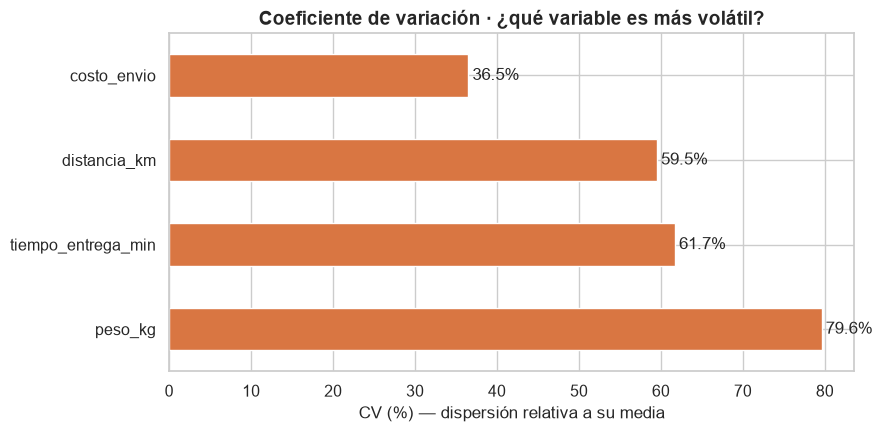

,CV (%)
peso_kg,79.60
tiempo_entrega_min,61.70
distancia_km,59.50
costo_envio,36.50


In [42]:
# ───────────────────────────────────────────────────────────────────────────────
# CV (coeficiente de variación) = desviación estándar ÷ media × 100
# Mide la dispersión RELATIVA en %: cuánto varían los datos comparado con su promedio.
# Pandas lo calcula en TODAS las columnas de "metricas" al mismo tiempo.
# .sort_values(ascending=False) = ordena de MAYOR a menor (descendente).
# ───────────────────────────────────────────────────────────────────────────────
cv = (df[metricas].std() / df[metricas].mean() * 100).round(1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))   # crea 1 figura con 1 solo eje, lo llamamos "ax"

# kind="barh" = barras HORIZONTALES (la "h" es de horizontal).
# ax=ax = dibuja en NUESTRO eje, no en uno nuevo.
# Importante: matplotlib decide solo el grosor de cada barra y dónde va.
# Las apila en posiciones fijas: y=0 (abajo), y=1, y=2, y=3 (arriba). Nosotros no controlamos eso.
cv.plot(kind="barh", ax=ax, color=NARANJA)

ax.set_title("Coeficiente de variación · ¿qué variable es más volátil?")  # título
ax.set_xlabel("CV (%) — dispersión relativa a su media")                  # etiqueta del eje X

# ───────────────────────────────────────────────────────────────────────────────
# Aquí ESCRIBIMOS la etiqueta de % sobre cada barra (las barras YA están dibujadas arriba).
#
# enumerate(cv) recorre la Serie y en cada vuelta entrega un par (i, v):
#     i = número de vuelta: 0, 1, 2, 3...  (un simple contador)
#     v = el valor del CV de esa fila: 79.6, 61.7...
#
# ¿Por qué usamos "i"? Porque matplotlib puso las barras en y=0, y=1, y=2, y=3,
# y nuestro contador "i" vale exactamente 0, 1, 2, 3. Coinciden por casualidad,
# ambos empiezan en 0. Así "i" nos dice SOBRE QUÉ BARRA cae cada texto.
#
# OJO: "i" NO cambia el tamaño ni el grosor de la barra. Solo indica la fila (altura
# en el eje Y) donde poner el texto. La barra ya existe; nosotros solo la etiquetamos.
#
# ax.text(x, y, texto) = escribe "texto" en la coordenada (x, y) del gráfico:
#     x = v+0.5   → un poquito a la derecha de la punta de la barra (0.5 de margen)
#     y = i       → la fila de esa barra (0, 1, 2 o 3)
#     va="center" → centra el texto verticalmente respecto a esa fila
#     f"{v}%"     → el número seguido del símbolo %, ej: "79.6%"
# ───────────────────────────────────────────────────────────────────────────────
for i, v in enumerate(cv):
    ax.text(v+0.5, i, f"{v}%", va="center")

plt.tight_layout()   # ajusta los márgenes para que no se corte nada
plt.show()           # dibuja el gráfico en pantalla

# .to_frame("CV (%)") = convierte la Serie en un DataFrame de una sola columna llamada "CV (%)",
# útil para mostrar los resultados como tabla ordenada en Jupyter.
cv.to_frame("CV (%)")

# La posición: cuartiles, percentiles y puntos atípicos

In [43]:
# df[metricas].describe() = método que calcula de golpe, para cada columna numérica:
#   count (nº de no-nulos), mean (media), std (desv. estándar), min (mínimo),
#   25% (Q1), 50% (mediana/Q2), 75% (Q3) y max (máximo). .round(2) redondea toda la tabla a 2 decimales.
df[metricas].describe().round(2)


,costo_envio,tiempo_entrega_min,distancia_km,peso_kg
count,"50,000.00","50,000.00","50,000.00","50,000.00"
mean,"8,380.67",47.21,5.76,3.15
std,"3,059.12",29.14,3.43,2.51
min,"2,102.00",5.00,0.61,0.16
25%,"6,075.00",34.40,3.42,1.54
50%,"7,939.00",42.90,4.96,2.46
75%,"10,101.00",51.80,7.17,3.94
max,"32,278.00",300.00,40.00,30.00
